### Goal:
#### Explore the fitness (age gender weight etc) dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

#### 1. Why This Project?
##### 1.Learn data cleaning with Pandas.
 
##### 2.Use NumPy for calculations (mean, median, etc.).
 
##### 3.Visualize trends using Matplotlib and Seaborn.
 
##### 4.Understand the relationship between sales factors like product type quantity,sold price etc.

### 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### 3. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\Final_data.csv")

### 4. Explore Data

In [3]:
print("Original Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample Data:\n", df.head())

Original Shape: (20000, 54)

Columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method', 'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets', 'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle', 'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin']

Sample Data:
      Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \


### 5. Data Cleaning

In [4]:
df.drop_duplicates(inplace=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Replace blank/empty strings with NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# Fill missing numeric values with column mean
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Show cleaning summary
print("\n✅ Data cleaned successfully!")
print("\nMissing values after cleaning:\n", df.isnull().sum())


✅ Data cleaned successfully!

Missing values after cleaning:
 age                               0
gender                            0
weight_(kg)                       0
height_(m)                        0
max_bpm                           0
avg_bpm                           0
resting_bpm                       0
session_duration_(hours)          0
calories_burned                   0
workout_type                      0
fat_percentage                    0
water_intake_(liters)             0
workout_frequency_(days/week)     0
experience_level                  0
bmi                               0
daily_meals_frequency             0
physical_exercise                 0
carbs                             0
proteins                          0
fats                              0
calories                          0
meal_name                         0
meal_type                         0
diet_type                         0
sugar_g                           0
sodium_mg                         0
c

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_6756\1379551432.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_6756\1379551432.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

### Insights:
 
1.Missing values were filled or removed.

2.Duplicates were dropped.

3.Data was ready for visualization and statistical analysis.

### 6. Analysis with NumPy & Pandas

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

if len(cat_cols) > 0 and len(num_cols) > 0:
    sample_cat = cat_cols[0]
    sample_num = num_cols[0]
    group_mean = df.groupby(sample_cat)[sample_num].mean()
    print(f"\nAverage {sample_num} by {sample_cat}:\n", group_mean)

#  NUMPY ANALYSIS
for col in num_cols:
    arr = df[col].to_numpy()
    print(f"\nColumn: {col}")
    print(f"  Mean: {np.mean(arr):.2f}")
    print(f"  Median: {np.median(arr):.2f}")
    print(f"  Std Dev: {np.std(arr):.2f}")
    print(f"  Percentiles (25%, 50%, 75%): {np.percentile(arr, [25,50,75])}")


Average age by gender:
 gender
Female    38.790218
Male      38.913032
Name: age, dtype: float64

Column: age
  Mean: 38.85
  Median: 39.86
  Std Dev: 12.11
  Percentiles (25%, 50%, 75%): [28.17  39.865 49.63 ]

Column: weight_(kg)
  Mean: 73.90
  Median: 70.00
  Std Dev: 21.17
  Percentiles (25%, 50%, 75%): [58.16 70.   86.1 ]

Column: height_(m)
  Mean: 1.72
  Median: 1.71
  Std Dev: 0.13
  Percentiles (25%, 50%, 75%): [1.62 1.71 1.8 ]

Column: max_bpm
  Mean: 179.89
  Median: 180.14
  Std Dev: 11.51
  Percentiles (25%, 50%, 75%): [170.0575 180.14   189.425 ]

Column: avg_bpm
  Mean: 143.70
  Median: 142.99
  Std Dev: 14.27
  Percentiles (25%, 50%, 75%): [131.22 142.99 156.06]

Column: resting_bpm
  Mean: 62.20
  Median: 62.20
  Std Dev: 7.29
  Percentiles (25%, 50%, 75%): [55.96 62.2  68.09]

Column: session_duration_(hours)
  Mean: 1.26
  Median: 1.27
  Std Dev: 0.34
  Percentiles (25%, 50%, 75%): [1.05 1.27 1.46]

Column: calories_burned
  Mean: 1280.11
  Median: 1231.45
  Std De

### Insights:
Average age of 
Female    38.790218
Male      38.913032


### 7. Visualization with Matplotlib

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_6756\947731998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_cols[0], y=num_cols[0], data=df, estimator=np.mean, palette='viridis')


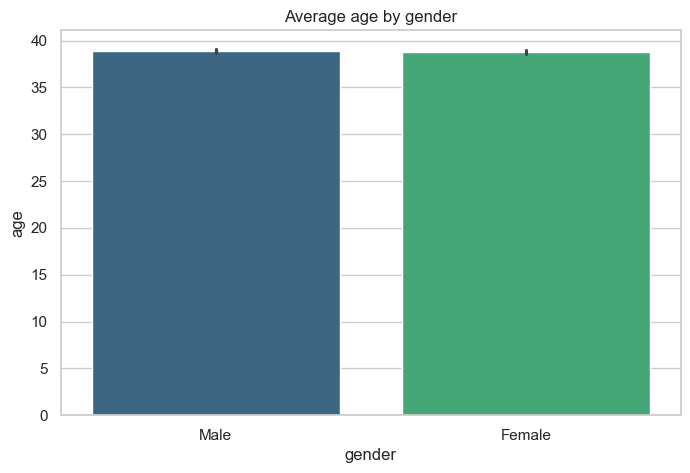

In [7]:

# Bar Chart:
if len(cat_cols) > 0 and len(num_cols) > 0:
    plt.figure(figsize=(8,5))
    sns.barplot(x=cat_cols[0], y=num_cols[0], data=df, estimator=np.mean, palette='viridis')
    plt.title(f'Average {num_cols[0]} by {cat_cols[0]}')
    plt.show()

#### Insights:
If females have a higher average sleep duration:

May reflect physiological or behavioral differences in sleep habits.

If males have lower sleep duration:

Could relate to higher stress, different routines, or underreporting.

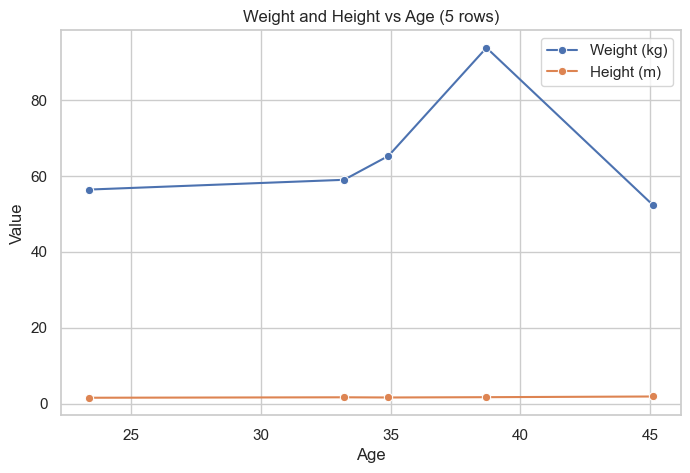

In [24]:
# Select the first 5 rows (or any 5 rows you prefer)
small_df = df_clean.head(5)

plt.figure(figsize=(8,5))
sns.lineplot(x='age', y='weight_(kg)', data=small_df, label='Weight (kg)', marker='o')
sns.lineplot(x='age', y='height_(m)', data=small_df, label='Height (m)', marker='o')

plt.title('Weight and Height vs Age (5 rows)')
plt.xlabel('Age')
plt.ylabel('Value')
plt.legend()
plt.show()


#### Insights:
 


### 8. Visualization with Seaborn

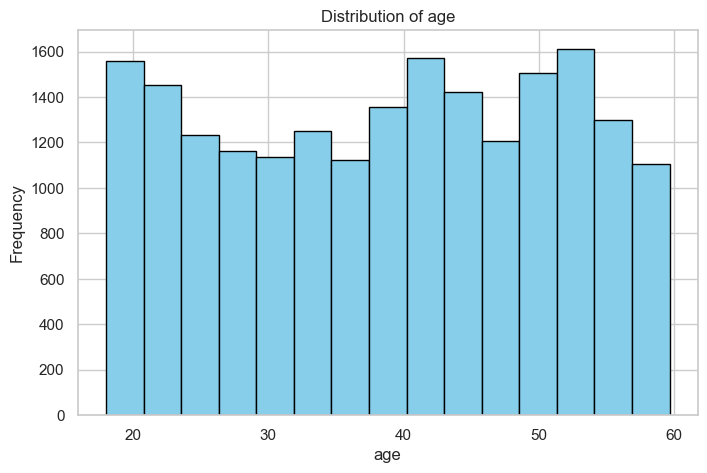

In [ ]:
## Histogram 
plt.figure(figsize=(8,5))
df[num_cols[0]].hist(bins=15, color='skyblue', edgecolor='black')
plt.title(f'Distribution of {num_cols[0]}')
plt.xlabel(num_cols[0])
plt.ylabel('Frequency')
plt.show()

### Insights:
The Weight (kg) values fluctuate noticeably across these 5 data points (ages 23, 33, 34, 38, 45). Weight ranges roughly from around 52 to 93 kg.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_6756\756240261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=cat_cols[0], data=df, palette='Set2')


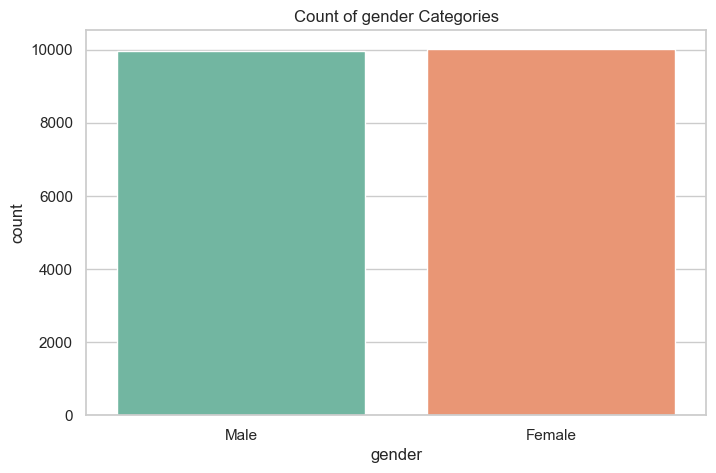

In [16]:
if len(cat_cols) > 0:
    plt.figure(figsize=(8,5))
    sns.countplot(x=cat_cols[0], data=df, palette='Set2')
    plt.title(f'Count of {cat_cols[0]} Categories')
    plt.show()

#### Insights:
 
1.Females survived more than males.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_6756\2496845936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_cols[0], y=num_cols[0], data=df, palette='coolwarm')


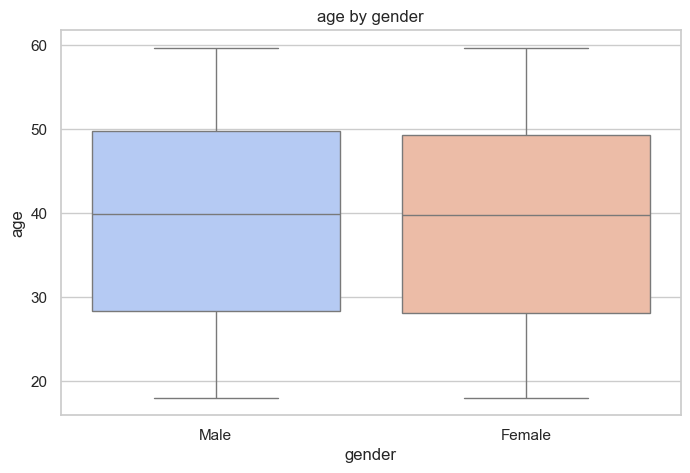

In [17]:

# --- Box Plot ---
if len(cat_cols) > 0 and len(num_cols) > 0:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=cat_cols[0], y=num_cols[0], data=df, palette='coolwarm')
    plt.title(f'{num_cols[0]} by {cat_cols[0]}')
    plt.show()

#### Insights:
1. Male has age around 50
2. If the median weight for males is higher than females, it suggests males tend to weigh more on average.

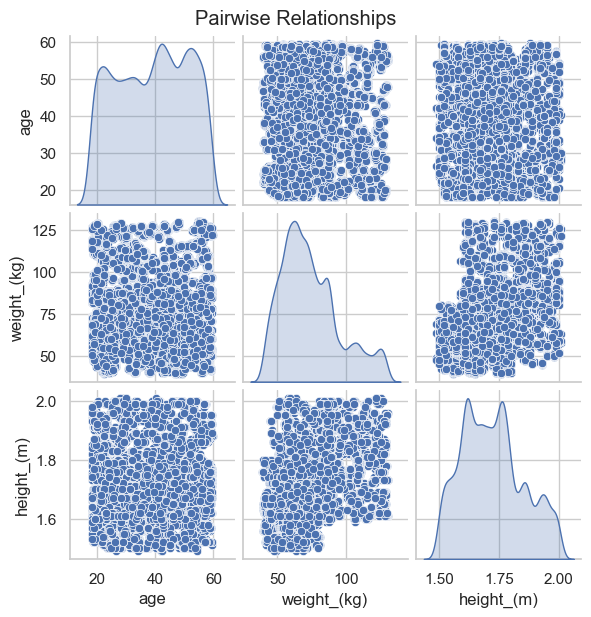

In [19]:
# --- Pair Plot ---
if len(num_cols) > 3:
    sns.pairplot(df[num_cols[:3]], diag_kind='kde', height=2.0)
    plt.suptitle('Pairwise Relationships', y=1.02)
    plt.show()

### Insights:
1. Age: The distribution of ages is relatively uniform between roughly 20 and 60.

2. Weight: Weight has a right-skewed distribution, with most people clustered around 50-80 kg  but with some heavier outliers.

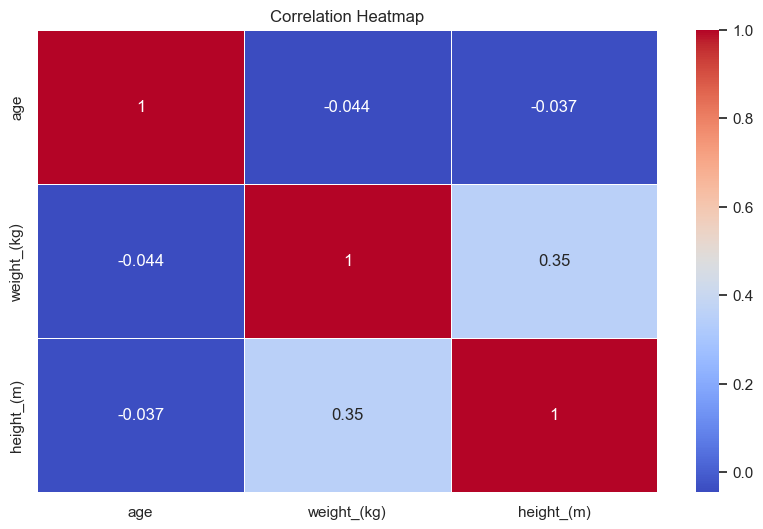

In [25]:
# Heatmap
plt.figure(figsize=(10,6))
cols = ['age', 'weight_(kg)', 'height_(m)']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Insights:
1. Weight_(kg) and height_(m) have a moderate positive correlation (0.35). This means taller people tend to weigh more, which fits common intuition.
